# Vantara — 02 Feature Engineering and Data Freeze

This notebook consumes the canonical STEP 02 feature table and STEP 03 schema evidence. Feature construction, leakage controls, correlation, VIF, and schema selection all live in reusable `src/` modules.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.analysis.eda import run_step03_analysis  # noqa: E402

summary = run_step03_analysis(ROOT / 'config/config.yaml', project_root=ROOT)
features = pd.read_parquet(ROOT / 'data/processed/customer_features_churn.parquet')
schema_path = ROOT / 'models_artifacts/churn_feature_schema.json'
schema = json.loads(schema_path.read_text())
{'feature_table_shape': features.shape, 'freeze_summary': summary}

{'feature_table_shape': (4952, 57),
 'freeze_summary': {'step': 'STEP 03',
  'schema_version': 'vantara-churn-features-v1',
  'selected_feature_count': 47,
  'excluded_feature_count': 5,
  'selected_features': ['frequency_orders',
   'avg_order_value',
   'avg_basket_units',
   'avg_distinct_products_per_order',
   'recency_days',
   'customer_tenure_days',
   'unique_product_count',
   'net_spend',
   'mean_interpurchase_gap_days',
   'variance_interpurchase_gap_days',
   'purchase_frequency_trend',
   'seasonal_purchase_concentration',
   'return_rate',
   'markdown_affinity_proxy',
   'mean_product_popularity',
   'median_product_popularity',
   'max_product_popularity',
   'rare_product_share',
   'category_affinity_01',
   'category_affinity_02',
   'category_affinity_03',
   'category_affinity_04',
   'category_affinity_05',
   'category_affinity_06',
   'category_affinity_07',
   'category_affinity_08',
   'category_affinity_09',
   'category_affinity_10',
   'category_affinity_

## Complete governed feature table

In [2]:
excluded_columns = {
    'customer_id',
    'cutoff_timestamp',
    'churn',
    'partition',
    'split_version',
}
feature_columns = [c for c in features.columns if c not in excluded_columns]
affinity_columns = [
    c for c in feature_columns if c.startswith('category_affinity_')
]
display(pd.DataFrame({'feature': feature_columns}))
{'complete_features': len(feature_columns), 'affinity_features': len(affinity_columns)}

,feature
0,frequency_orders
1,gross_spend
2,avg_order_value
3,avg_basket_units
4,avg_distinct_products_per_order
5,recency_days
6,customer_tenure_days
7,unique_product_count
8,net_spend
9,historical_customer_value


{'complete_features': 52, 'affinity_features': 31}

## Training-only correlation evidence

,feature_a,feature_b,correlation,absolute_correlation
0,net_spend,historical_customer_value,1.000000,1.000000
1,gross_spend,historical_customer_value,0.992885,0.992885
2,gross_spend,net_spend,0.992885,0.992885


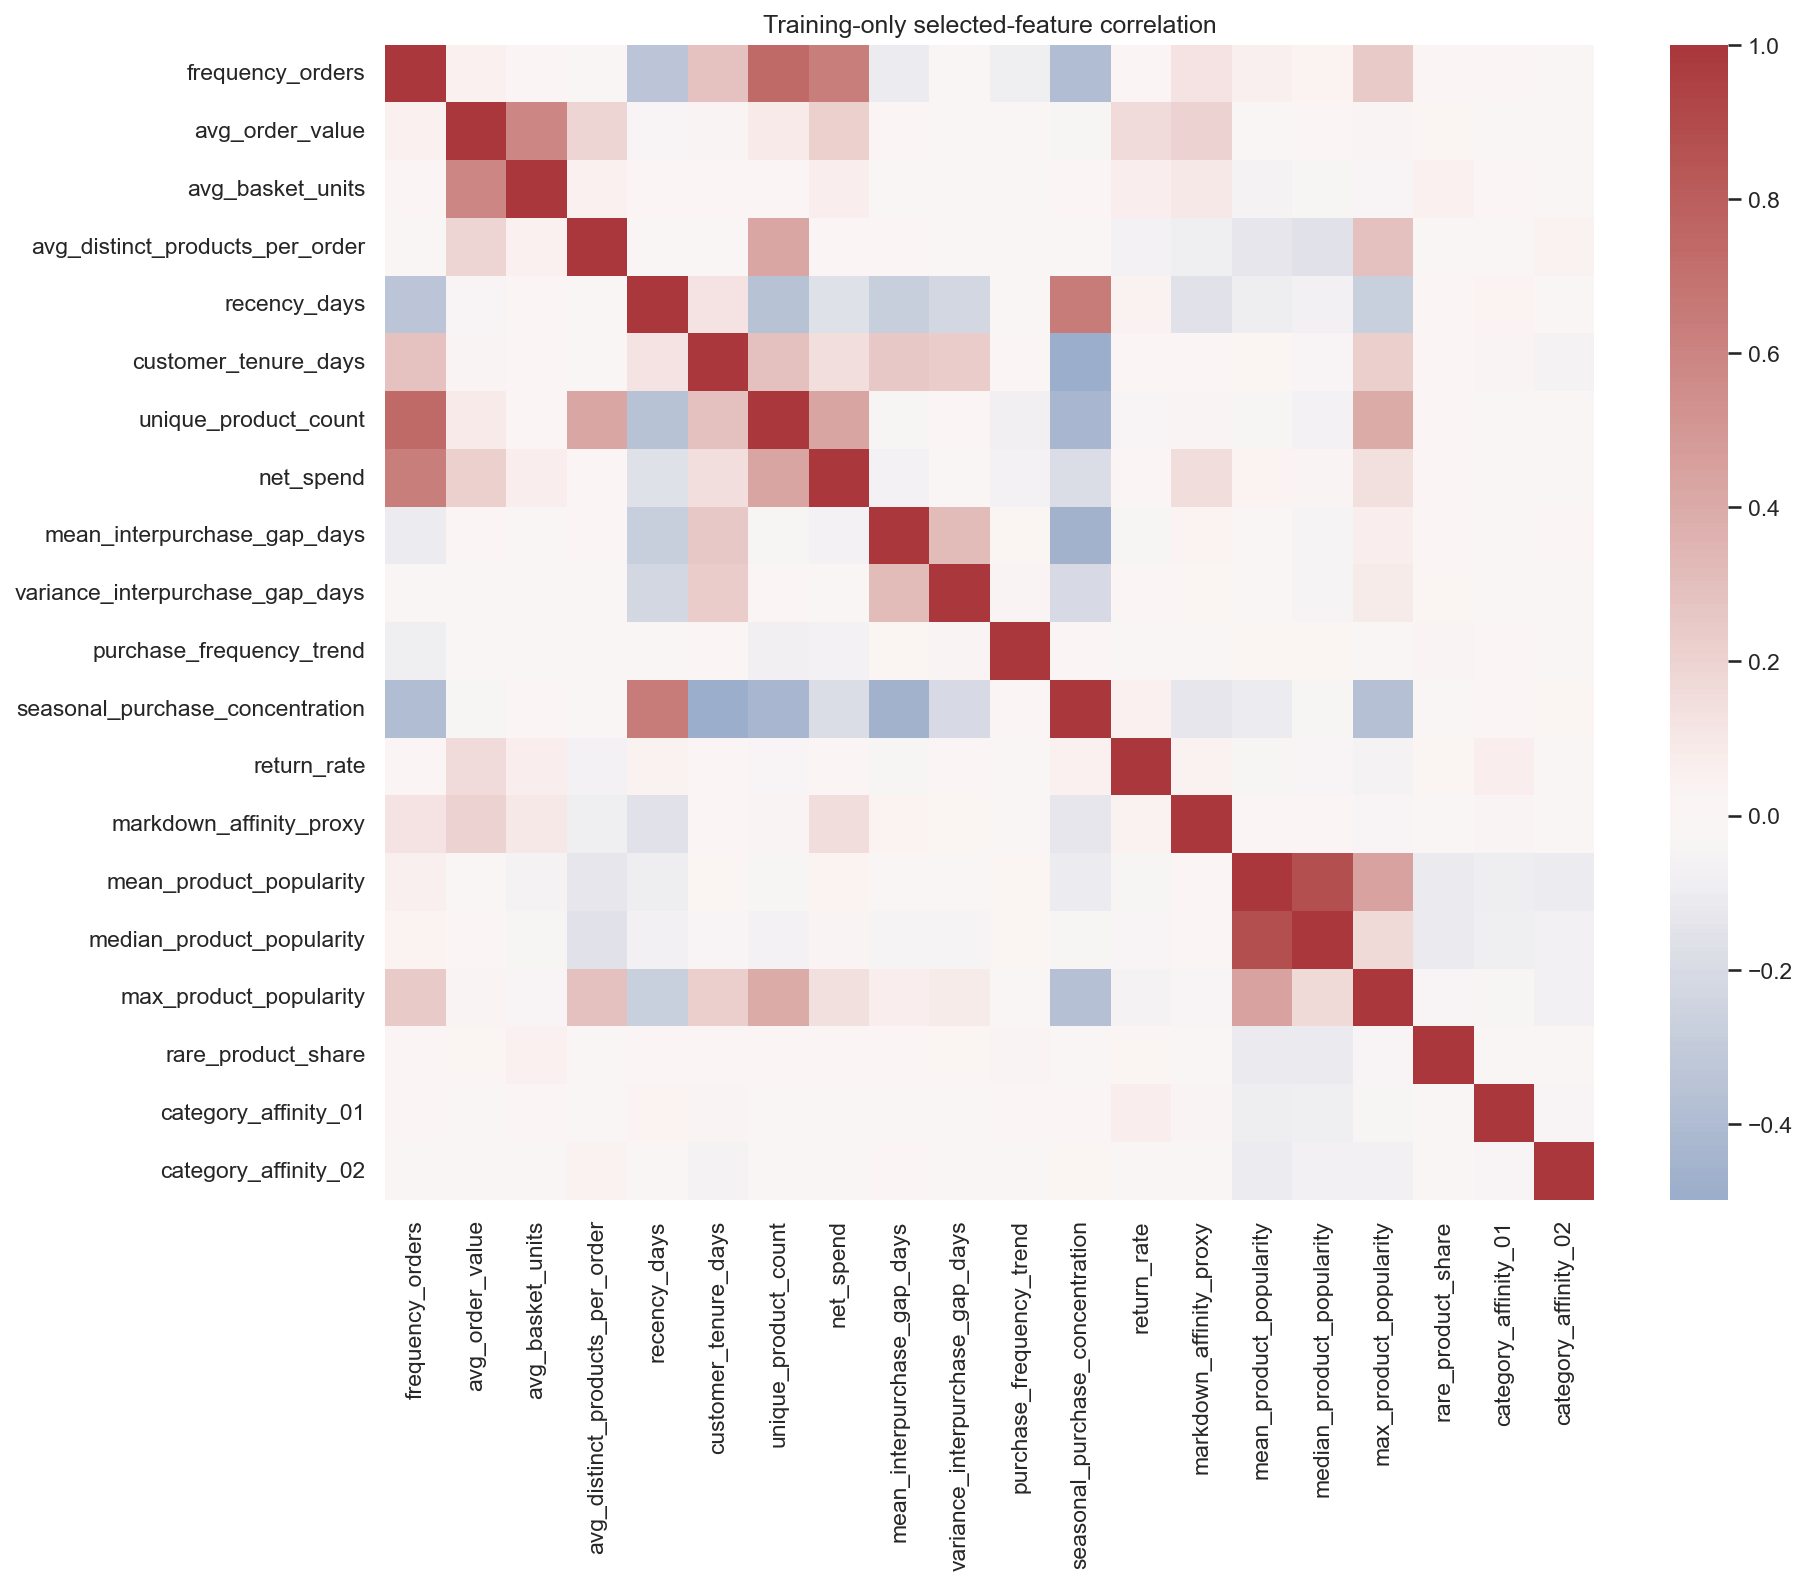

In [3]:
freeze_dir = ROOT / 'reports/data_freeze'
display(pd.read_csv(freeze_dir / 'high_correlation_pairs.csv'))
display(Image(filename=str(ROOT / 'reports/eda/selected_feature_correlation.png')))

## VIF evidence before and after selection

In [4]:
display(pd.read_csv(freeze_dir / 'vif_initial.csv').head(20))
display(pd.read_csv(freeze_dir / 'vif_final.csv').head(20))

,feature,vif
0,category_affinity_00,45.749312
1,category_affinity_10,40.423935
2,category_affinity_20,24.135735
3,category_affinity_03,21.869736
4,category_affinity_05,17.081263
5,engagement_score,15.997336
6,category_affinity_06,15.712737
7,category_affinity_25,14.877702
8,category_affinity_27,14.073940
9,category_affinity_15,13.958530


,feature,vif
0,mean_product_popularity,9.512558
1,median_product_popularity,7.147814
2,seasonal_purchase_concentration,5.013988
3,unique_product_count,4.417710
4,recency_days,4.276070
5,frequency_orders,4.248278
6,customer_tenure_days,3.306339
7,max_product_popularity,2.853755
8,avg_distinct_products_per_order,2.106965
9,avg_order_value,1.872510


## Frozen churn model feature order

In [5]:
display(pd.DataFrame({'selected_feature': schema['selected_features']}))
exclusions = [
    {'excluded_feature': key, 'reason': value}
    for key, value in schema['exclusions'].items()
]
display(pd.DataFrame(exclusions))
{'schema_version': schema['schema_version'], 'feature_count': schema['feature_count']}

,selected_feature
0,frequency_orders
1,avg_order_value
2,avg_basket_units
3,avg_distinct_products_per_order
4,recency_days
5,customer_tenure_days
6,unique_product_count
7,net_spend
8,mean_interpurchase_gap_days
9,variance_interpurchase_gap_days


,excluded_feature,reason
0,category_affinity_00,Training VIF 45.749312 exceeded 10.00.
1,category_affinity_unknown,Reference category removed from model matrix; ...
2,engagement_score,Training VIF 15.896621 exceeded 10.00.
3,gross_spend,Highly correlated with net_spend; net revenue ...
4,historical_customer_value,Exact duplicate of net_spend in the current go...


{'schema_version': 'vantara-churn-features-v1', 'feature_count': 47}

## Data-freeze decision

The complete business feature table is preserved. The frozen model schema removes only a reference affinity category, exact/redundant monetary relationships, zero-variance inputs, or features exceeding the configured training-only VIF gate. All six classical churn models and the ANN must consume this exact versioned order.